## A tutorial on synthetic null data generation

As described in the accompanying manuscript, simple permutations of the labels of the observations in the original dataset could be a good starting point for generating in silico negative control data and can suffice for the analysis of differences between groups. However, the permutation of labels may not suffice to generate a valid null distribution in certain settings (e.g. when the effect of interest involves changes in trajectories, spatial organization, etc). In such cases, sophisticated models that are either generic or domain-adapted (like being specific to particular omics types or a particular technology (e.g. single cell)) could be used to generate synthetic null data. For instance, __knockoffs__ are a class of methods that are able to generate synthetic null data while preserving the intrinsic dependence structure of the original datasets. However, knockoffs require knowledge of the joint distribution of features and are computationally intensive because of the strict requirement of exchangeability, where swapping any subset of features with their knockoff counterparts requires preserving the joint distribution of all the original features and knockoffs. Novel frameworks such as SyNPar have been proposed recently that generate synthetic null data efficiently and easily by overcoming the challenges of knockoffs. Generic synthetic data generation libraries (e.g. __sdv__ also include copula-based models and deep generative models that can preserve either the dependence structure and/or the marginal statistical properties of the datasets. Here, we demonstrate the use of the __sdv__ library to generate synthetic null data using copula-based models.

In [4]:
import os
import timeit
import numpy as np
import pandas as pd
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import Metadata
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

#### Generating synthetic data using the sdv library

The code chunk below contains a bunch of functions that we use to either generate synthetic data or assess the similarity between real-world and synthetic data. When we use those functions later, more context is provided.

In [5]:
def generate_synthetic_data(data_path, output_dir):
    start = timeit.default_timer()
    data = np.loadtxt(data_path, delimiter="\t")
    data = pd.DataFrame(data)
    metadata = Metadata.detect_from_dataframe(
        data=data,
        table_name='my_methylation_data')
    synthesizer = GaussianCopulaSynthesizer(metadata)
    print("Fitting the synthesizer to the data...")
    synthesizer.fit(data)
    print("Sampling synthetic data...")
    new_data = synthesizer.sample(num_rows=200)
    stop = timeit.default_timer()
    execution_time_minutes = (stop - start) / 60
    print(f"Time taken to generate synthetic data: {execution_time_minutes} minutes")
    new_data.to_csv(os.path.join(output_dir, "synthetic_data_with_copulas.tsv"), sep="\t", index=False)


def compare_correlations(original_data_file, synthetic_data_file):
    original_data = np.loadtxt(original_data_file, delimiter="\t")
    synthetic_data = np.loadtxt(synthetic_data_file, delimiter="\t")
    original_corr = estimate_realworld_corrcoef_distribution(original_data)
    synthetic_corr = estimate_realworld_corrcoef_distribution(synthetic_data)
    print("Original data correlation coefficient distribution:")
    print(original_corr)
    print("Synthetic data correlation coefficient distribution:")
    print(synthetic_corr)


def draw_ecdf_plots(original_data_file, synthetic_data_file):
    original_data = np.loadtxt(original_data_file, delimiter="\t")
    synthetic_data = np.loadtxt(synthetic_data_file, delimiter="\t")
    original_corr_mat = determine_correlation_matrix(original_data)
    original_corr_mat = np.triu(original_corr_mat, k=1)
    synthetic_corr_mat = determine_correlation_matrix(synthetic_data)
    synthetic_corr_mat = np.triu(synthetic_corr_mat, k=1)
    original_corr_values = original_corr_mat.flatten()
    synthetic_corr_values = synthetic_corr_mat.flatten()
    draw_ecdf(original_corr_values, synthetic_corr_values, labels=('Original Data', 'Synthetic Data'))


def draw_ecdf(data1, data2, labels=('Dataset 1', 'Dataset 2'), colors=('blue', 'red')):
    def ecdf(data):
        """Compute ECDF for a one-dimensional array of measurements."""
        n = len(data)
        x = np.sort(data)
        y = np.arange(1, n + 1) / n
        return x, y

    x1, y1 = ecdf(data1)
    x2, y2 = ecdf(data2)

    plt.figure(figsize=(8, 6))
    plt.plot(x1, y1, marker='.', linestyle='none', color=colors[0], label=labels[0])
    plt.plot(x2, y2, marker='.', linestyle='none', color=colors[1], label=labels[1])
    plt.xlabel('Data points')
    plt.ylabel('ECDF')
    plt.legend(loc='lower right')
    plt.title('ECDF Plot')
    plt.grid(True)
    plt.savefig('ecdf_plot.png', dpi=300)
    plt.show()


def estimate_realworld_corrcoef_distribution(feature_matrix: np.ndarray) -> list:
    """

    :param feature_matrix: A ndimensional numpy array containing features in columns
    :return: A list of tuples, where each tuple represents an interval of correlation coefficient range. The tuples
    are constructed based on empirical quantiles of correlation coefficients in one of the triangles of correlation
    coefficient matrix on a sample of real-world data.
    """
    corr_mat = determine_correlation_matrix(feature_matrix)
    corr_mat = np.triu(corr_mat, k=1)
    quantiles = np.percentile(corr_mat, np.arange(0, 101, 5))
    intervals = [(round(quantiles[i], 2), round(quantiles[i + 1], 2)) for i in range(len(quantiles) - 1)]
    return intervals


def determine_correlation_matrix(feature_matrix: np.ndarray) -> np.ndarray:
    """
    Given a feature matrix with features in columns (a ndimensional numpy array), this function
    computes the spearman rank correlation coefficients between each feature and returns a matrix of correlation
    coefficients as ndimensional numpy array.

    :param feature_matrix: A ndimensional numpy array with features in columns
    :return: A ndimensional numpy array of pairwise correlation coefficients between each feature
    """
    return spearmanr(feature_matrix).statistic


We first use the sdv library's GaussianCopula-based synthesizer and generate a new synthetic dataset based on our input dataset (in this case the file named "id~8697.tsv"). The input data contains 200 observations and 10,000 features. The synthetic data

In [6]:
generate_synthetic_data("id~8697.tsv", ".")

/opt/homebrew/Caskroom/miniforge/base/envs/fdr_hacking/lib/python3.10/site-packages/sdv/single_table/base.py:104: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Fitting the synthesizer to the data...
Sampling synthetic data...
Time taken to generate synthetic data: 13.439986857633357 minutes


Here, the goal/need of the synthetic null data is to encapsulate the inherent dependence structure in the original data, as we were anyway going define the groups randomly when comparing group differences using statistical testing. Therefore, the most important aspect of assessing the similarity between real and synthetic dataset is to check that the dependence structure is similar between real and synthetic datasets. One possible way of checking for this in this specific case is by inspecting the distribution of correlation coefficients and comparing between real and synthetic datasets. We do that here in two different ways: (a) First, we print the intervals for every 5th percentile in the correlation coefficient distribution, and (b) we visualize empirical cumulative distribution function (ECDF) plots.

In [7]:
compare_correlations("id~8697.tsv", "synthetic_data_with_copulas.tsv")

Original data correlation coefficient distribution:
[(-0.89, -0.1), (-0.1, -0.06), (-0.06, -0.02), (-0.02, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.01), (0.01, 0.04), (0.04, 0.08), (0.08, 0.12), (0.12, 0.21), (0.21, 0.56), (0.56, 0.9)]
Synthetic data correlation coefficient distribution:
[(-0.97, -0.09), (-0.09, -0.03), (-0.03, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.02), (0.02, 0.06), (0.06, 0.11), (0.11, 0.12), (0.12, 0.12), (0.12, 0.19), (0.19, 0.53), (0.53, 1.0)]


The above shows that the proportion of correlation coefficients that are within a given range of strength of correlation are similar between real and synthetic datasets. Next we visualize the same using ECDF plots.

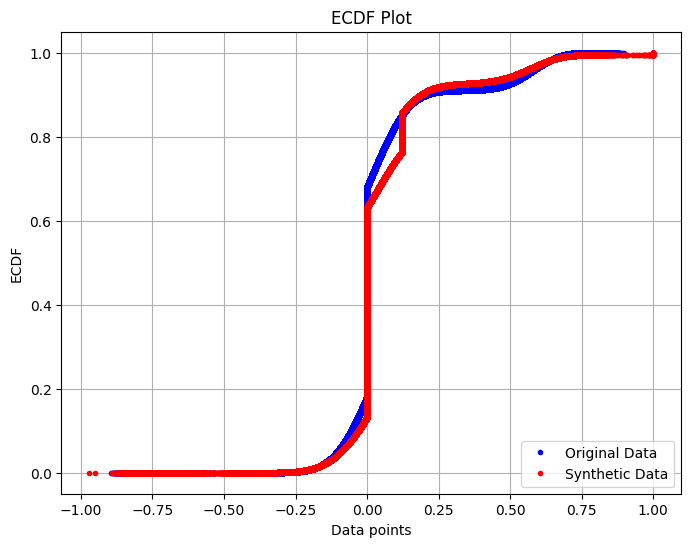

In [8]:
draw_ecdf_plots("id~8697.tsv", "synthetic_data_with_copulas.tsv")

The above chart shows that the ECDFs of the correlation coefficients in the real and synthetic datasets are similar, indicating that the synthetic data has preserved the dependence structure of the original data.